In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.rcParams['figure.figsize'] = (9, 5)
df = pd.read_excel(r'C:\Users\Lucy.Bravo\Downloads\MexicoGDP.xlsx')
df.columns = ['Periodo', 'GDP']
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


In [36]:
df.describe()

,Periodo,GDP,Periodo_norm,GDP_norm
count,62.000000,6.200000e+01,62.000000,62.000000
mean,1990.500000,4.866155e+11,0.984908,0.369951
std,18.041619,4.544804e+11,0.008927,0.345520
min,1960.000000,1.304000e+10,0.969817,0.009914
25%,1975.250000,8.336062e+10,0.977363,0.063375
50%,1990.500000,2.885511e+11,0.984908,0.219372
75%,2005.750000,8.944031e+11,0.992454,0.679973
max,2021.000000,1.315351e+12,1.000000,1.000000


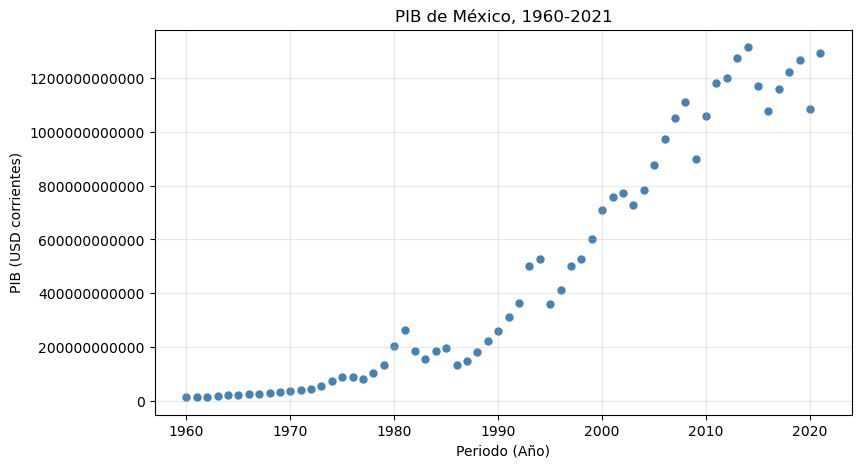

In [12]:
plt.scatter(df['Periodo'], df['GDP'], color='steelblue', s=25)
plt.xlabel('Periodo (Año)')
plt.ylabel('PIB (USD corrientes)')
plt.title('PIB de México, 1960-2021')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
##La serie muestra un comportamiento de tipo creciente con forma
#aproximadamente "S" (lento al inicio, acelerado después de los años 80-90 y con
#indicios de desaceleración/variabilidad hacia el final de la muestra), lo cual
#justifica intentar un modelo logístico.
#Nótese que la variable (el año) toma valores del orden de
#(entre 1960 y 2021), mientras que (el PIB) toma valores del orden de a
#El modelo logístico, en el dominio de la funcion, solo puede tomar valores de 0 a 1 en los numeros reales.

In [24]:
#Ajuste del modelo logístioc a los datos originales

X = df['Periodo'].values.astype(float)
Y = df['GDP'].values.astype(float)

def logistic(x, b1, b2):
    return 1 / (1 + np.exp(b1 * (x - b2)))
# Intento de ajuste con datos originales (sin transformar)
p0 = [-0.1, 1990] # valores iniciales razonables
popt_raw, pcov_raw = curve_fit(logistic, X, Y, p0=p0, maxfev=20000)
print('Beta1 estimado:', popt_raw[0])
print('Beta2 estimado:', popt_raw[1])
print('Matriz de covarianza:')
print(pcov_raw)

Beta1 estimado: -0.1
Beta2 estimado: -197010.0009489058
Matriz de covarianza:
[[inf inf]
 [inf inf]]


C:\Users\Lucy.Bravo\AppData\Local\Temp\ipykernel_13284\105236566.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_raw, pcov_raw = curve_fit(logistic, X, Y, p0=p0, maxfev=20000)


In [ ]:
##Beta2 termina en un valor muy grande y muy lejos del rango real de los años (1960–2021).
#La matriz de covarianza no puede estimarse de forma confiabl señal de que el algoritmo noencontró un mínimo bien definido.

In [25]:
#Calculando que tan malo es el ajuste, calculando R2
def sse(params, x, y):
    b1, b2 = params
    pred = logistic(x, b1, b2)
    return np.sum((y - pred)**2)
def r2_score(y, pred):
    ss_res = np.sum((y - pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res/ss_tot
pred_raw = logistic(X, *popt_raw)
print('Rango de predicciones (Y_hat):', pred_raw.min(), '-', pred_raw.max())
print('SSE con parámetros estimados: {:.4e}'.format(sse(popt_raw, X, Y)))
print('SSE con un juego de parámetros "razonable" (b1=-0.1, b2=1990): {:.4e}'.format(sse([-0.1, 1990], X, Y)))
print('R2 del ajuste "raw":', r2_score(Y, pred_raw))

Rango de predicciones (Y_hat): 1.0 - 1.0
SSE con parámetros estimados: 2.7281e+25
SSE con un juego de parámetros "razonable" (b1=-0.1, b2=1990): 2.7281e+25
R2 del ajuste "raw": -1.1652077038443713


**Sí, hubo un problema serio elmodelo, tal como está planteado, es esencialmente inestimable con los datos
en su escala original.**

La causa es un **desajuste de escalas** entre el rango del modelo y el rango
de la variable dependiente:

1. Por construcción, $\hat{Y}=\dfrac{1}{1+e^{\beta_1(X-\beta_2)}}$ solo puede
   tomar valores en el intervalo $(0,1)$, independiente de Beta1 y beta2
2. El PIB real ($Y$) tiene valores del orden de $10^{10}$–$10^{12}$.
3. El residuo $(Y-\hat{Y})\approx Y$ para cualqueir
   combinación de parámetros, ya que $\hat Y$ nunca puede acercarse a la
   magnitud de $Y$. Esto significa que la suma de cuadrados del error (SSE)
   es prácticamente constante (dominada por $\sum Y^2$) en toda la región
   razonable del espacio de parámetros 
4. Como la función de pérdida es casi plana con respecto a $\beta_1$ y
   $\beta_2$, el gradiente es aproximadamente cero en casi todo el dominio.
   El algoritmo de optimización  no tiene
   ninguna dirección de descenso clara que seguir, y cno converge a un minimo real.
   Asi que vamos a normalizar los datos

In [29]:
#Normalizando los datos
df['Periodo_norm'] = df['Periodo'] / df['Periodo'].max()
df['GDP_norm'] = df['GDP'] / df['GDP'].max()
df[['Periodo', 'Periodo_norm', 'GDP', 'GDP_norm']].head()


,Periodo,Periodo_norm,GDP,GDP_norm
0,1960,0.969817,1.304000e+10,0.009914
1,1961,0.970312,1.416000e+10,0.010765
2,1962,0.970807,1.520000e+10,0.011556
3,1963,0.971301,1.696000e+10,0.012894
4,1964,0.971796,2.008000e+10,0.015266


In [30]:
print('Rango de Periodo_norm:', df['Periodo_norm'].min(), '-', df['Periodo_norm'].max())
print('Rango de GDP_norm:     ', df['GDP_norm'].min(), '-', df['GDP_norm'].max())

Rango de Periodo_norm: 0.9698169223156853 - 1.0
Rango de GDP_norm:      0.009913702259391078 - 1.0


In [31]:
#Ajuste del modelo

In [32]:
Xn = df['Periodo_norm'].values
Yn = df['GDP_norm'].values

p0_n = [-50, 0.98]  # nuevo punto inicial, acorde a la nueva escala de Xn (cercana a 1)
popt_n, pcov_n = curve_fit(logistic, Xn, Yn, p0=p0_n, maxfev=20000)

perr_n = np.sqrt(np.diag(pcov_n))

print('Beta1 estimado:', popt_n[0], '  (error estándar:', perr_n[0], ')')
print('Beta2 estimado:', popt_n[1], '  (error estándar:', perr_n[1], ')')

Beta1 estimado: -271.59742569745373   (error estándar: 11.490393555573812 )
Beta2 estimado: 0.9892938979925399   (error estándar: 0.0001713873415228336 )


In [33]:
#Calculo de R2
pred_n = logistic(Xn, *popt_n)
r2_n = r2_score(Yn, pred_n)
print('R2 del ajuste normalizado:', r2_n)

R2 del ajuste normalizado: 0.9780236969948942


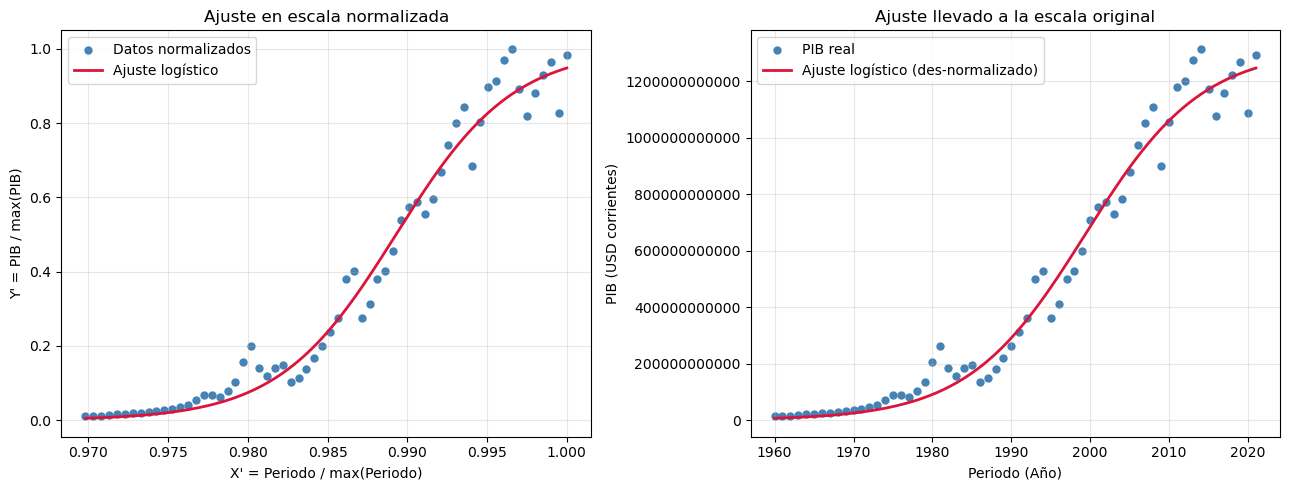

In [35]:
#Gráfica normalizada y en escala real
x_line = np.linspace(Xn.min(), Xn.max(), 300)
y_line = logistic(x_line, *popt_n)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(Xn, Yn, color='steelblue', s=25, label='Datos normalizados')
axes[0].plot(x_line, y_line, color='crimson', linewidth=2, label='Ajuste logístico')
axes[0].set_xlabel("X' = Periodo / max(Periodo)")
axes[0].set_ylabel("Y' = PIB / max(PIB)")
axes[0].set_title('Ajuste en escala normalizada')
axes[0].legend()
axes[0].grid(alpha=0.3)

# regresamos a la escala original para visualizar el ajuste sobre el PIB real
years_line = x_line * df['Periodo'].max()
gdp_line = y_line * df['GDP'].max()

axes[1].scatter(df['Periodo'], df['GDP'], color='steelblue', s=25, label='PIB real')
axes[1].plot(years_line, gdp_line, color='crimson', linewidth=2, label='Ajuste logístico (des-normalizado)')
axes[1].set_xlabel('Periodo (Año)')
axes[1].set_ylabel('PIB (USD corrientes)')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].set_title('Ajuste llevado a la escala original')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tras normalizar ambas columnas dividiendo entre su máximo, el
algoritmo de mínimos cuadrados no lineales converge a una solución estable y
con sentido y los errores de beta1 y beta2 son minimos.

Antes deestimar los parámetros de un modelo, es indispensable verificar que
el rango de la función propuesta sea compatible con el rango de la
variable que se quiere predecir, o normalizar los datos para que lo sea.

## ¿Obtuvo resultados satisfactorios en esta ocasión?

**Sí, en términos generales el ajuste normalizado fue satisfactorio.** El
coeficiente de determinación fue $R^2 \approx 0.978$, es decir, el modelo
logístico explica cerca del 98% de la variabilidad del PIB (una vez
normalizado). Además, a diferencia del primer intento, aquí el algoritmo sí
convergió a un mínimo estable: los errores estándar de $\beta_1$ y $\beta_2$
son pequeños y con sentido, y la matriz de covarianza pudo calcularse sin
problemas.

### Bondad de ajuste, a detalle

- **Visualmente**, la curva logística sigue de cerca la forma en "S" de los
  datos tanto en la escala normalizada como al regresar a la escala real del
  PIB: crecimiento lento entre 1960 y mediados de los 90, una aceleración
  marcada a partir de esa década, y un aplanamiento hacia el final de la
  muestra.
- **Las mayores desviaciones** entre el modelo y los datos reales ocurren en
  los años con crisis económicas puntuales (por ejemplo, la crisis de la
  deuda de 1982 o la crisis del "error de diciembre" de 1994-1995), donde el
  PIB real cae o se estanca de forma abrupta. El modelo logístico es una
  curva **suave y monótona** (siempre creciente), por lo que, por
  construcción, no puede capturar caídas temporales o choques económicos —
  solo describe la tendencia de fondo de largo plazo.
- En otras palabras, el $R^2$ alto confirma que el modelo captura muy bien la
  **tendencia general** de crecimiento del PIB, pero no está diseñado para
  capturar la **volatilidad de corto plazo** asociada a crisis específicas.
  Para eso se necesitaría un modelo distinto (por ejemplo, uno con
  componentes cíclicos o de series de tiempo).

In [37]:
# Pronóstico del PIB para el año 2022
X_2022 = 2022.0

# Paso 1: normalizar el nuevo dato de X usando el MISMO máximo que usamos al entrenar
X_2022_norm = X_2022 / df['Periodo'].max()   # OJO: se usa el máximo de entrenamiento (2021), no uno nuevo

# Paso 2: predecir en la escala normalizada, con los parámetros ya ajustados (popt_n)
Y_2022_norm = logistic(X_2022_norm, *popt_n)

# Paso 3: des-normalizar multiplicando por el máximo de GDP usado al entrenar
Y_2022 = Y_2022_norm * df['GDP'].max()

print('X 2022 normalizado:', X_2022_norm)
print('Pronóstico Y normalizado:', Y_2022_norm)
print('Pronóstico PIB 2022 (USD corrientes): {:,.2f}'.format(Y_2022))

X 2022 normalizado: 1.000494804552202
Pronóstico Y normalizado: 0.9544418586826325
Pronóstico PIB 2022 (USD corrientes): 1,255,426,228,423.57


## Mecanismo de transformación para pronosticar

Como el modelo se ajustó con variables **normalizadas** (no con los valores
originales), para pronosticar cualquier año nuevo hay que aplicar el mismo
proceso de tres pasos, siempre usando los **mismos valores de referencia**
que se usaron al entrenar el modelo:

1. **Normalizar el nuevo dato de entrada:** dividir el nuevo año (2022) entre
   el mismo $\max(X)$ usado en el entrenamiento (2021), **no** entre un nuevo
   máximo recalculado con el dato nuevo incluido.
2. **Predecir en la escala normalizada:** evaluar el modelo logístico ya
   ajustado, $\hat Y' = \dfrac{1}{1+e^{\beta_1(X'-\beta_2)}}$, con los
   parámetros $\beta_1$ y $\beta_2$ obtenidos en el entrenamiento.
3. **Des-normalizar el resultado:** multiplicar la predicción por el mismo
   $\max(Y)$ (el PIB máximo histórico usado al entrenar), para regresar la
   predicción a las unidades reales de PIB (USD corrientes).

**Punto importante:** como la curva logística tiene una asíntota superior en
$Y'=1$ (es decir, en $Y=\max(Y)$ del periodo de entrenamiento), el modelo
**nunca puede pronosticar un PIB mayor al máximo histórico observado**; solo
se acerca a él poco a poco. Esta es una limitación estructural del modelo
logístico para pronosticar crecimiento futuro más allá de lo ya observado,
y es algo a tener en cuenta al interpretar el pronóstico de 2022.